Importing Libraries

In [200]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

Computing Risk Neutral Probabilities

In [201]:
def probabilities(Rf,u,T,N):
    pu = (np.exp(Rf*T/N) - (1/u))/(u - (1/u))
    pd = 1 - pu

    return pu, pd

Creating Stock Price Tree

In [202]:
def build_stock(S0, u, N):
    tree = np.zeros((N+1,N+1))
    for i in range(N+1):  
        for j in range(i+1):     
            tree[i][j] = S0 * (u**j) * ((1/u)**(i-j))
    return tree

Calculating option pricing

In [203]:
def bin_tree(S0, X, Rf, sig, T, N, option_type, exercise):
    u = np.exp(sig*np.sqrt(T/N))
    pu, pd = probabilities(Rf, u, T, N)
    tree = build_stock(S0, u, N)

    opt = np.zeros((N+1, N+1))
    for j in range(N+1):
        if option_type == 'call':
            opt[N][j] = max(tree[N][j] - X, 0)
        else:
            opt[N][j] = max(X - tree[N][j], 0)

    discount =  np.exp(-1*Rf*(T/N))
    for i in range(N-1, -1, -1):
        for j in range(i+1):
            continuation = discount * (pu * opt[i+1][j+1] + pd * opt[i+1][j])
            if exercise == 'american':
                if option_type == 'call':
                    intrinsic = max(tree[i][j] - X, 0)
                else:
                    intrinsic = max(X - tree[i][j], 0)
                opt[i][j] = max(continuation, intrinsic)
            else:
                opt[i][j] = continuation
    
    return opt[0][0]
    

In [204]:
bin_tree(100,100,0.05,0.2,1,500,'call','european')

np.float64(10.44658513644654)

Implementing Greeks

In [205]:
def greek_compute(S0, X, Rf, sig, T, N, option_type, exercise):
    eps = 1
    epv = 0.01
    dt = 1/365

    P0 = bin_tree(S0, X, Rf, sig, T, N, option_type, exercise)
    Pu = bin_tree(S0+eps, X, Rf, sig, T, N, option_type, exercise)
    Pd = bin_tree(S0-eps, X, Rf, sig, T, N, option_type, exercise)
    Puv = bin_tree(S0, X, Rf, sig+epv, T, N, option_type, exercise)
    Pdv = bin_tree(S0, X, Rf, sig-epv, T, N, option_type, exercise)
    Pt = bin_tree(S0, X, Rf, sig, T-dt, N, option_type, exercise)

    return [round(P0,2),round((Pu-Pd)/(2*eps),4),round((Pu - 2*P0 + Pd)/(eps**2),4),round((Puv - Pdv)/(2*epv),4),round((Pt-P0)/eps/365,4)] 

    

In [206]:
greek_compute(100,100,0.05,0.2,1,500,'call','european')

[np.float64(10.45),
 np.float64(0.6368),
 np.float64(0.0335),
 np.float64(37.5022),
 np.float64(-0.0)]

Simulating Greeks for Range of Stock Prices

In [207]:
def simulating_greeks(S_start, S_end, X, Rf, sig, T, N, option_type, exercise):
    d = {}
    for i in range(S_start, S_end, 1):
        d[i] = greek_compute(i,100,0.05,0.2,1,10,'call','european')
    return d

In [208]:
d = simulating_greeks(60,100,70,0.05,0.2,1,10,'call','european')

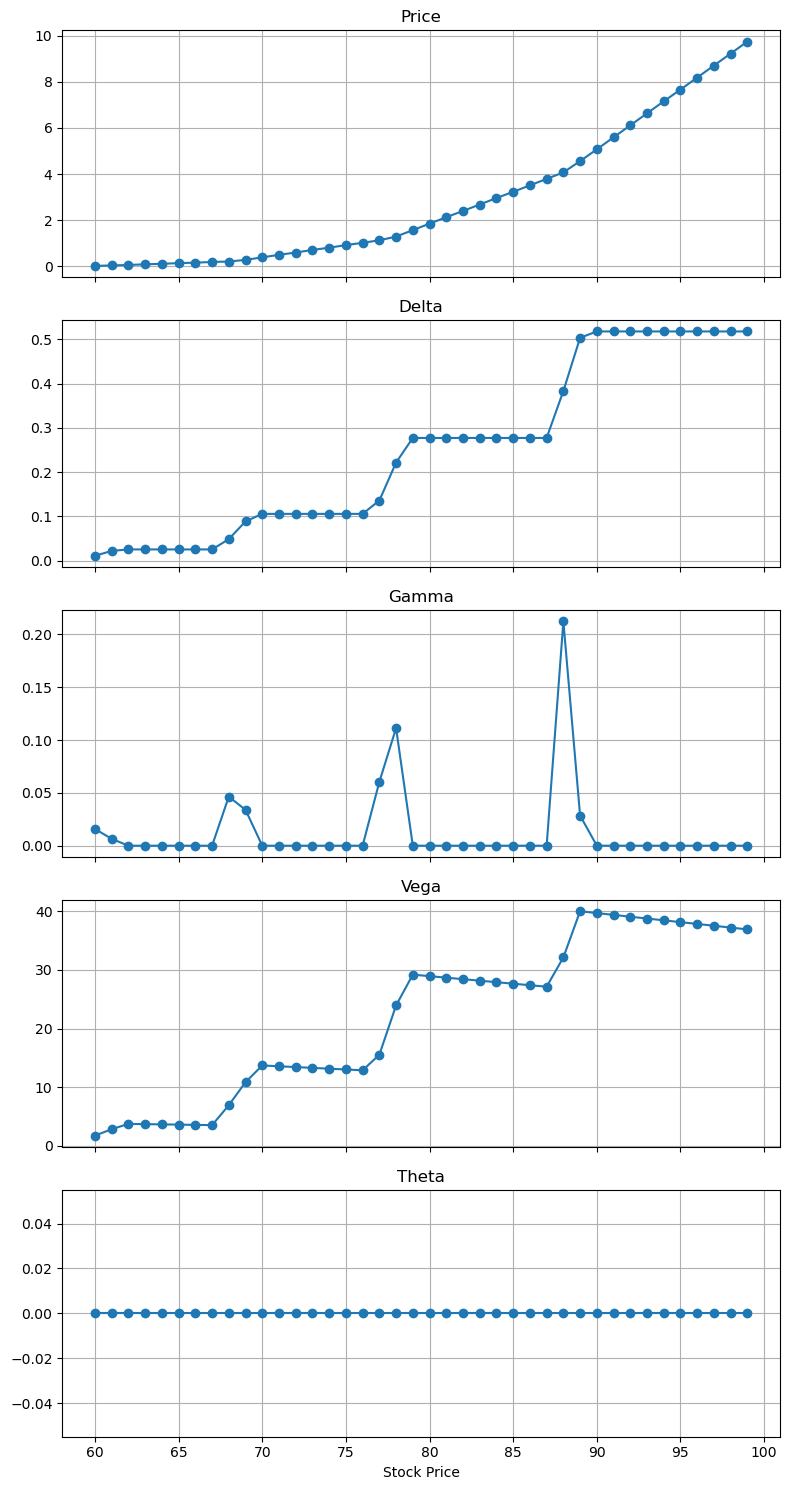

In [231]:
x = sorted(d.keys())
n_pos = len(d[x[0]])

metric_name = ['Price','Delta','Gamma','Vega','Theta']

fig, axes = plt.subplots(n_pos, 1, figsize=(8, 3*n_pos), sharex=True)

for pos in range(n_pos):
    y = [d[k][pos] for k in x]

    metric = metric_name[pos] if pos < len(metric_name) else f"Metrics :{pos}"
    axes[pos].plot(x, y, marker='o')
    axes[pos].set_title(metric)
    axes[pos].grid(True)

axes[-1].set_xlabel('Stock Price')

plt.tight_layout()
plt.savefig("figures/greek_plots.png", dpi=300)
plt.show()

Black Scholes Model


In [232]:
def black_scholes(S0, X, r, T, sigma, option_type='call'):
    d1 = (np.log(S0/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    if option_type == 'call':
        return S0*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)
    else:
        return K*np.exp(-r*T)*norm.cdf(-d2) - S0*norm.cdf(-d1)

bs_price = black_scholes(100, 100, 0.05, 1, 0.20, 'call')

Analysis for N Stages

Running N from 5 to 100 with a step size of 5

In [233]:
start_n = 5
end_n = 100
x = list(range(start_n,end_n+1,5))

In [234]:
def n_stage_analysis(start_n, end_n, S0, X, Rf, sig, T, option_type, exercise):
    bin_price = []
    errors = []
    for i in range(start_n,end_n + 1,5):
        t = bin_tree(S0, X, Rf, sig, T, i, option_type, exercise)
        bin_price.append(t)
        e = abs(bs_price - t)
        errors.append(e)

    return bin_price, errors

In [235]:
bin_price, errors = n_stage_analysis(5, 100, 100,100,0.05,0.2,1,'call','european')

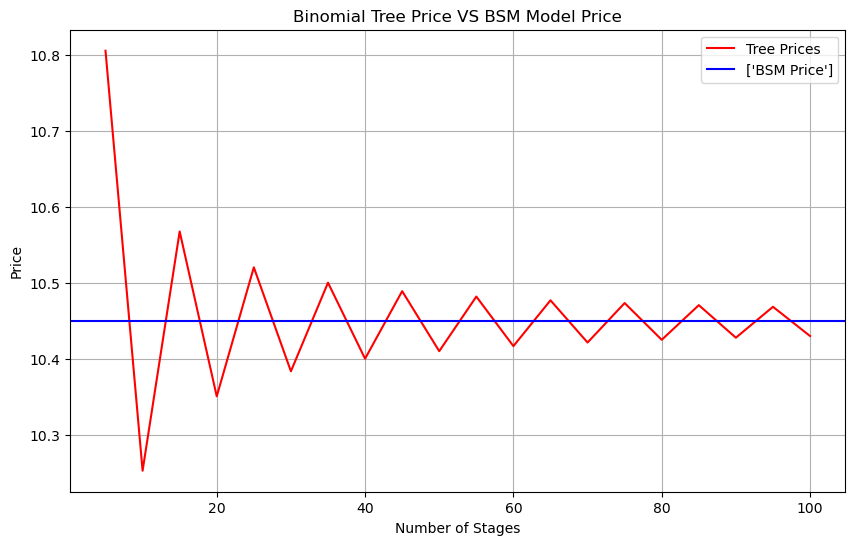

In [236]:
plt.figure(figsize=(10,6))
plt.plot(x,bin_price, color='r', label=['Tree Prices'])
plt.axhline(bs_price, color='b', label=['BSM Price'])
plt.grid(True)
plt.title('Binomial Tree Price VS BSM Model Price')
plt.legend()
plt.xlabel('Number of Stages')
plt.ylabel('Price')
plt.savefig("figures/binomial_vs_bsm.png", dpi=300)
plt.show()

Error Plotting

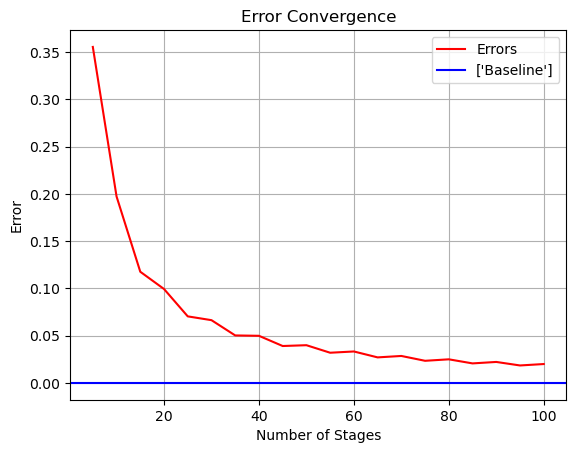

In [237]:
plt.plot(x,errors, color = 'r', label=['Errors'])
plt.axhline(0, color='b', label=['Baseline'])
plt.grid(True)
plt.legend()
plt.title('Error Convergence')
plt.xlabel('Number of Stages')
plt.ylabel('Error')
plt.savefig("figures/convergence.png", dpi=300)
plt.show()